In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Applications of clustering

### Example 1: Identifying patterns 

In [3]:
data = pd.read_csv('fremont.csv',parse_dates=True,index_col='Date')
data.head()

,"Fremont Bridge Sidewalks, south of N 34th St","Fremont Bridge Sidewalks, south of N 34th St Cyclist East Sidewalk","Fremont Bridge Sidewalks, south of N 34th St Cyclist West Sidewalk"
Date,,,
2022-08-01 00:00:00,23.0,7.0,16.0
2022-08-01 01:00:00,12.0,5.0,7.0
2022-08-01 02:00:00,3.0,0.0,3.0
2022-08-01 03:00:00,5.0,2.0,3.0
2022-08-01 04:00:00,10.0,2.0,8.0


In [20]:
data.columns[0]

'Fremont Bridge Sidewalks, south of N 34th St'

In [21]:
data_table = pd.pivot_table(data = data, values = data.columns[0], 
                            index = data.index.time, 
                            columns = data.index.date)
data_table

,2012-10-03,2012-10-04,2012-10-05,2012-10-06,2012-10-07,2012-10-08,2012-10-09,2012-10-10,2012-10-11,2012-10-12,...,2023-08-22,2023-08-23,2023-08-24,2023-08-25,2023-08-26,2023-08-27,2023-08-28,2023-08-29,2023-08-30,2023-08-31
00:00:00,13.0,18.0,11.0,15.0,11.0,9.0,12.0,15.0,21.0,17.0,...,8.0,10.0,7.0,14.0,27.0,28.0,8.0,7.0,6.0,13.0
01:00:00,10.0,3.0,8.0,15.0,17.0,4.0,3.0,3.0,10.0,13.0,...,1.0,4.0,3.0,12.0,15.0,14.0,4.0,3.0,6.0,6.0
02:00:00,2.0,9.0,7.0,9.0,3.0,5.0,4.0,3.0,13.0,5.0,...,8.0,5.0,6.0,3.0,10.0,5.0,5.0,2.0,5.0,3.0
03:00:00,5.0,3.0,4.0,3.0,6.0,5.0,8.0,4.0,2.0,7.0,...,4.0,3.0,1.0,0.0,4.0,1.0,3.0,4.0,4.0,6.0
04:00:00,7.0,8.0,9.0,5.0,3.0,5.0,9.0,5.0,12.0,5.0,...,11.0,4.0,13.0,11.0,3.0,5.0,8.0,11.0,11.0,10.0
05:00:00,31.0,26.0,25.0,5.0,9.0,23.0,31.0,25.0,12.0,14.0,...,26.0,27.0,25.0,28.0,12.0,5.0,33.0,16.0,32.0,25.0
06:00:00,155.0,142.0,105.0,27.0,17.0,137.0,153.0,149.0,43.0,87.0,...,119.0,100.0,111.0,73.0,59.0,18.0,110.0,85.0,103.0,112.0
07:00:00,352.0,319.0,319.0,33.0,26.0,327.0,368.0,340.0,304.0,183.0,...,326.0,335.0,291.0,181.0,54.0,35.0,191.0,256.0,289.0,271.0
08:00:00,437.0,418.0,370.0,105.0,69.0,457.0,462.0,435.0,404.0,268.0,...,528.0,446.0,464.0,267.0,72.0,63.0,344.0,390.0,407.0,409.0
09:00:00,276.0,241.0,212.0,114.0,103.0,278.0,275.0,255.0,189.0,145.0,...,332.0,307.0,306.0,151.0,128.0,102.0,239.0,246.0,264.0,243.0


In [22]:
# fill missing values
data_table.fillna(method='ffill',
                  axis=1,
                  inplace=True)

<AxesSubplot:title={'center':'hourly bicycle traffic'}, xlabel='time'>

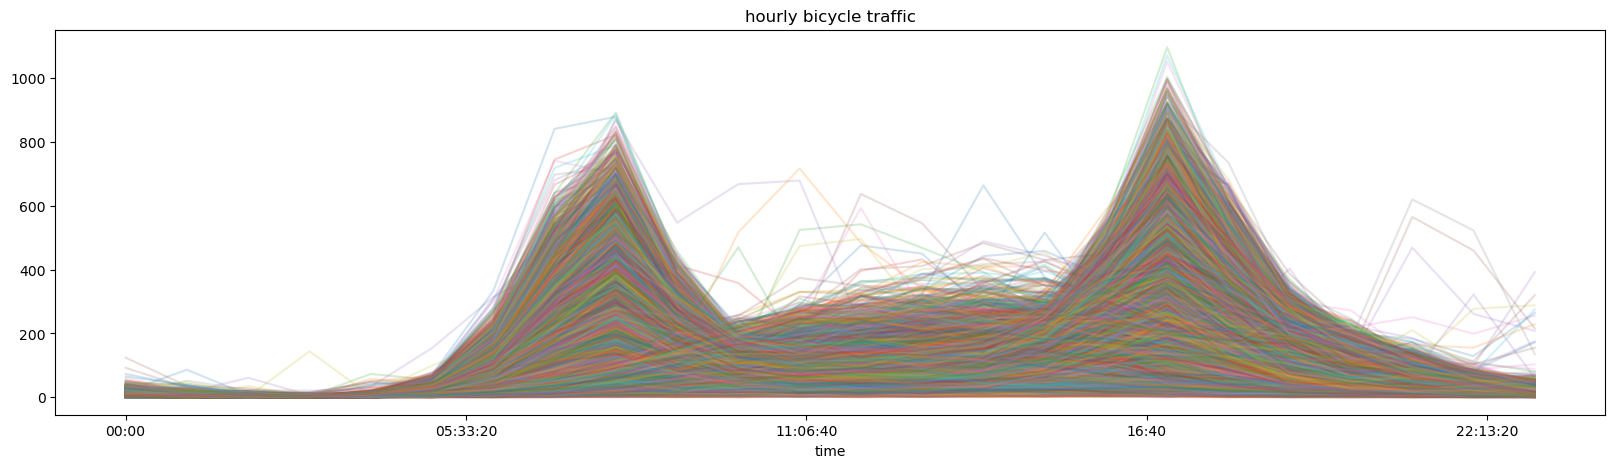

In [23]:
data_table.plot(legend=False,
                alpha=0.2, 
                figsize=(20,5), 
                title='hourly bicycle traffic')
#plt.title('hourly bicycle traffic (2012-2021)',fontsize=20)

In [24]:
days = data_table.T
from sklearn.cluster import KMeans

/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warning

Text(0, 0.5, 'inertia')

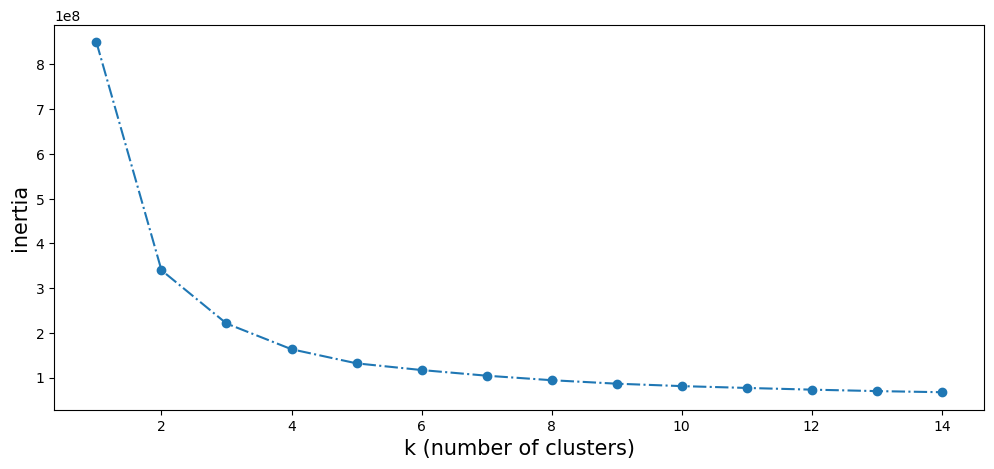

In [25]:
k_list = np.arange(1,15)
inertias = []
for k in k_list:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(days)
    inertias.append(kmeans.inertia_)
    
plt.figure(figsize=(12,5))
plt.plot(k_list,inertias,'o-.')
plt.xlabel('k (number of clusters)', fontsize=15)
plt.ylabel('inertia', fontsize=15)

In [8]:
# k=2,3,4 seems a good choice

/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


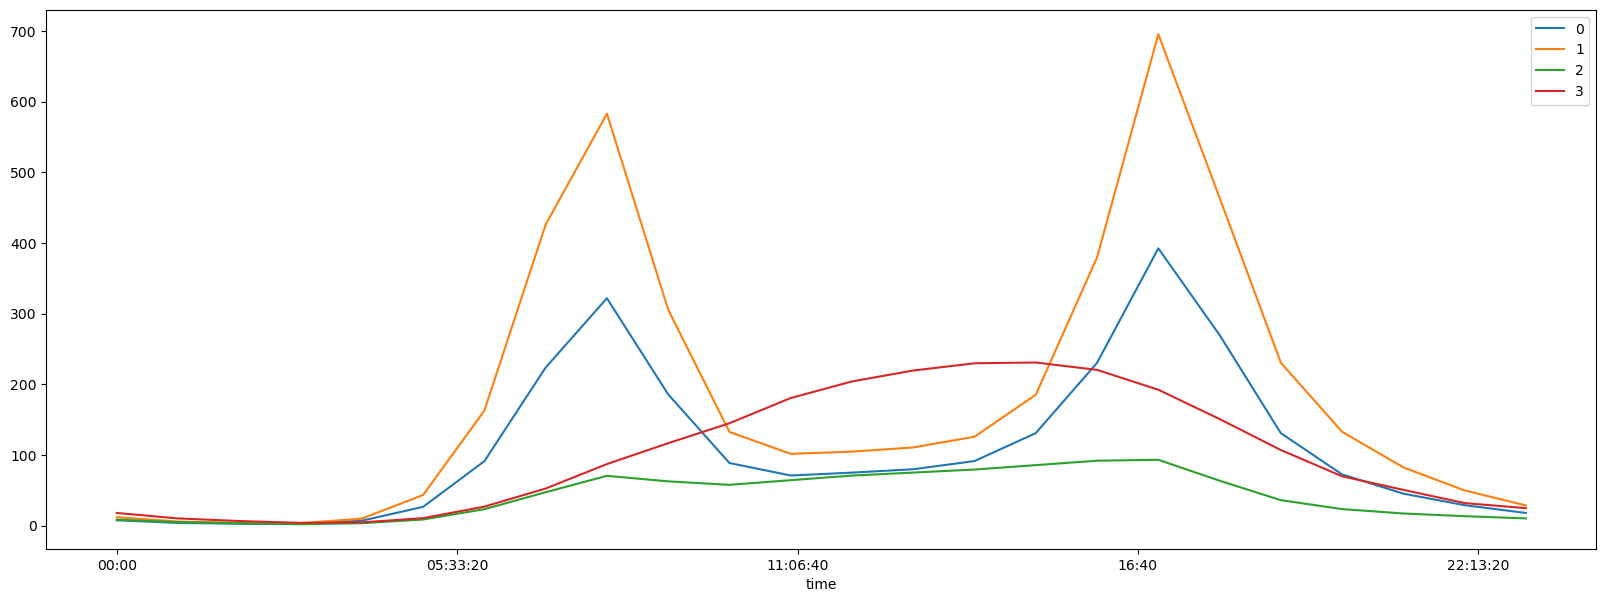

In [26]:
k = 4
cluster = KMeans(n_clusters=k)
cluster.fit(days)

centers = cluster.cluster_centers_
labels = cluster.labels_

cluster_centers = pd.DataFrame(centers.T, index=data_table.index)

# plot cluster centers
fig, ax = plt.subplots(figsize=(20,7))
for i in range(k):
    cluster_centers[i].plot(ax=ax)
plt.legend()

<AxesSubplot:xlabel='time'>

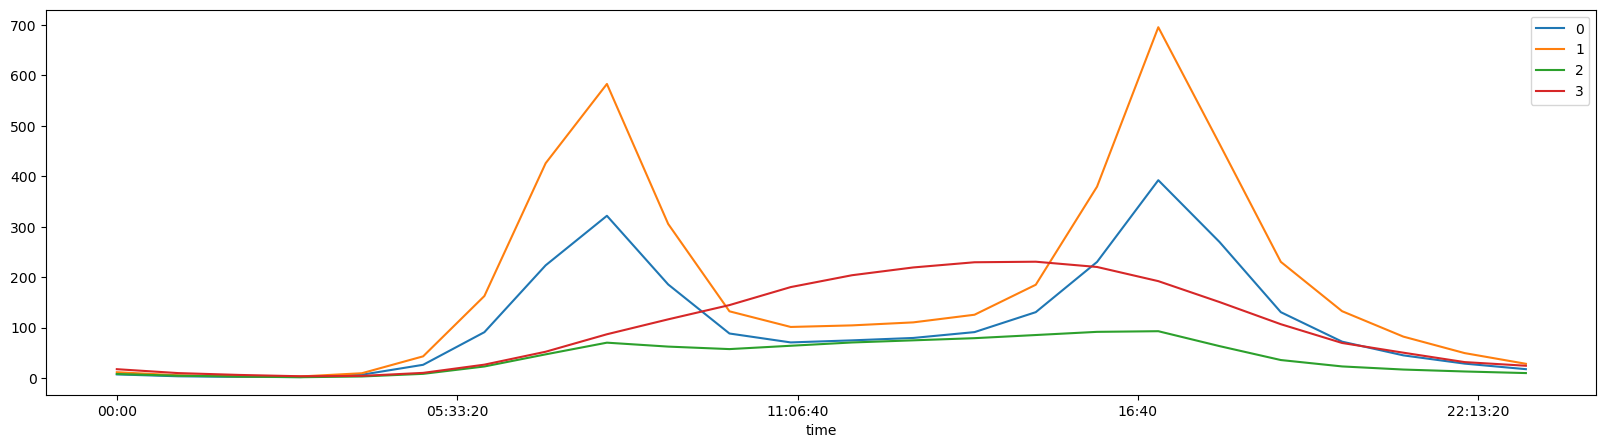

In [27]:
cluster_centers.plot(figsize=(20,5))

In [11]:
# clusters 0,2: weekdays
# clusters 1,3: weekends and holidays

In [28]:
pd.to_datetime(days[labels==0].index).dayofweek.value_counts()

4    296
2    283
3    280
1    271
0    250
6      1
dtype: int64

In [29]:
pd.to_datetime(days[labels==1].index).dayofweek.value_counts()

1    222
2    212
3    189
0    177
4    116
dtype: int64

## Example 2: image segmentation

The goal is to partition an image into multiple segments. In this example, we will cluster pixels based on color intensities (color segmentation).

In [30]:
import matplotlib.pyplot as plt

In [32]:
# load image
image = plt.imread('https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/Tova_the_cat.png')

(-0.5, 293.5, 219.5, -0.5)

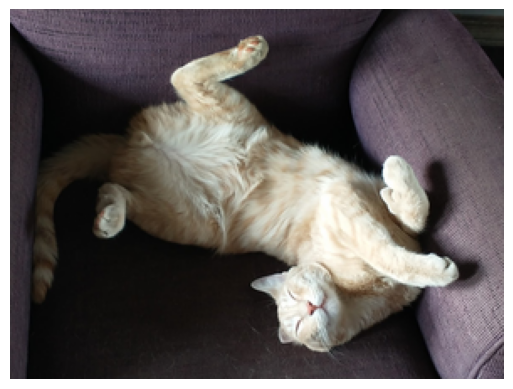

In [33]:
# display image
plt.imshow(image)
plt.axis(False)

In [34]:
# 220x294 pixels (3 color channels, red, green and blue)
image.shape

(220, 294, 3)

In [35]:
# reshape the array to get a long list of RGB colors
X = image.reshape(220*294,3)

In [36]:
from sklearn.cluster import KMeans

/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


(-0.5, 293.5, 219.5, -0.5)

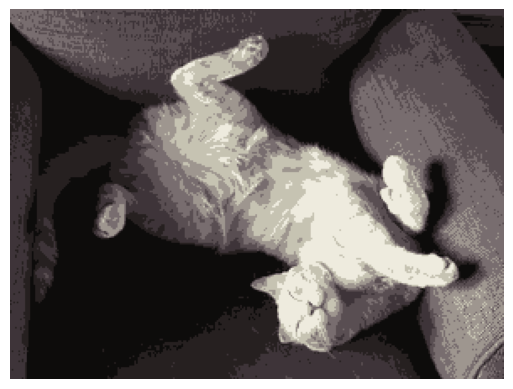

In [43]:
# cluster colors
k = 8
kmeans = KMeans(n_clusters=k)
kmeans.fit(X)
centers = kmeans.cluster_centers_
labels = kmeans.labels_
# replace each color by its cluster center
segmented_image = centers[labels].reshape(220,294,3)
# display segmented image
plt.imshow(segmented_image)
plt.axis(False)

## Example 3: topic modeling

The goal is to discover the latent "topics'' that occur in a collection of documents.

In [44]:
from sklearn.datasets import fetch_20newsgroups

In [45]:
categories = [
    'alt.atheism',
    'comp.windows.x',
    'rec.autos',
    'rec.sport.baseball',
    'sci.electronics',
    'sci.space',
]

docs = fetch_20newsgroups(subset='all', 
                                categories=categories,
                                remove=('headers', 'footers', 'quotes')
                          )

In [46]:
data = pd.DataFrame({'doc' : docs['data'], 
                           'category' : docs['target']})
data.head()

,doc,category
0,\n McDonnell Douglas rolls out DC-X\n\n ...\...,5
1,\nPortuguese launch complex??? Gosh.... Polish...,5
2,^^^...,4
3,[reply to jimh@carson.u.washington.edu (James ...,0
4,Let's look at the effects of inflation on 1930...,3


In [47]:
docs['target_names']

['alt.atheism',
 'comp.windows.x',
 'rec.autos',
 'rec.sport.baseball',
 'sci.electronics',
 'sci.space']

In [48]:
# preprocess docs
import nltk 
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
nltk.download('wordnet')  
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def process_pos(pos):
    if pos.startswith('J'): # adjectives
        return wordnet.ADJ
    elif pos.startswith('V'): # verbes
        return wordnet.VERB
    elif pos.startswith('N'): # nouns
        return wordnet.NOUN
    elif pos.startswith('R'): # adverbs
        return wordnet.ADV
    else:
        return wordnet.NOUN
    
from nltk.corpus import stopwords
stop_words = stopwords.words('english')

import string
punctuation = [punc for punc in string.punctuation]

def process_text(text):
    words = word_tokenize(text)
    words = [word.lower() for word in words]
    lemmatized_words = [lemmatizer.lemmatize(word, pos=process_pos(pos)) 
                        for word,pos in nltk.pos_tag(words) 
                        if word not in stop_words # remove stop words
                        and word not in punctuation # remove punctuations
 ] 
    return ' '.join(lemmatized_words)

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vanmagnan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vanmagnan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/vanmagnan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/vanmagnan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/vanmagnan/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [49]:
data['processed_doc'] = data.doc.apply(process_text)

In [50]:
data.processed_doc[0]

"mcdonnell douglas roll dc-x ... ssto research remain cloudy sdi organization -- pay 60 million dc-x -- ca n't afford fund full development follow-on vehicle get necessary hundred million require little peculiar way put sdio 's budget year 3-4 billion _could_ fund dc development one year budget course iron fire launcher development primary purpose dc development could easily pay divert money divert comparable sts ops budget ... oh flame start applaud sdio fund dc-x devlopment hope work launcher development nasas primary goal either imho suppose provide enable technology research others launcher development secondarily operate launcher require that's"

In [51]:
# word frequencies
from sklearn.feature_extraction.text import TfidfVectorizer
vect = TfidfVectorizer(stop_words='english', ngram_range = (1,1),max_df=0.8, max_features=15000)

In [52]:
X = vect.fit_transform(data.processed_doc)

In [53]:
k = 15
kmeans = KMeans(n_clusters=k)
kmeans.fit(X)
labels = kmeans.labels_

/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [54]:
# clusters = topics?
cluster = 14
data.loc[labels==cluster,'category'].value_counts()

4    58
2     8
5     3
3     1
Name: category, dtype: int64

In [55]:
# put word frequencies into a dataframe
words_df = pd.DataFrame(data = X.toarray(),columns=vect.get_feature_names_out())
words_df

,00,000,0000,00000,00000074,001,0060,007,01,011,...,zombie,zond,zone,zoo,zoom,zooming,zt,zupcic,zw,zx
0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.491384,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5737,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5738,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5739,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5740,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
words_df[labels==5].mean().sort_values(ascending=False).head(10)

thanks         0.115776
mail           0.063731
advance        0.051012
know           0.041305
hi             0.041299
list           0.040502
appreciate     0.038878
info           0.030852
information    0.030502
send           0.027247
dtype: float64

In [57]:
# top 10 words in each cluster 
for i in range(k):
    print('cluster '+str(i))
    print('---------------------------')
    print(words_df[labels==i].mean().sort_values(ascending=False).head(10).index.to_list())
    print('---------------------------')

cluster 0
---------------------------
['use', 'power', 'work', 'chip', 'circuit', 'like', 'output', 'battery', 'high', 'know']
---------------------------
cluster 1
---------------------------
['window', 'use', 'server', 'widget', 'file', 'display', 'run', 'application', 'program', 'motif']
---------------------------
cluster 2
---------------------------
['detector', 'radar', 'geico', 'ka', 'detect', 'use', 'valentine', 'police', 'law', 'band']
---------------------------
cluster 3
---------------------------
['space', 'nasa', 'shuttle', 'launch', 'program', 'station', 'sci', 'think', 'gov', 'moon']
---------------------------
cluster 4
---------------------------
['car', 'engine', 'drive', 'oil', 'buy', 'new', 'good', 'like', 'know', 'speed']
---------------------------
cluster 5
---------------------------
['thanks', 'mail', 'advance', 'know', 'hi', 'list', 'appreciate', 'info', 'information', 'send']
---------------------------
cluster 6
---------------------------
['phone', 'delet

## Example 4: Customer segmentation

Customer segmentation is the process of dividing customers into groups based on common characteristics

In [58]:
data = pd.read_csv('Mall_Customers.csv', index_col='CustomerID')
data.columns = ['gender','age','income','score']
data.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Mall_Customers.csv'

The dataset contains the basic information (ID, age, gender, income, spending score) about the customers.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.cluster import KMeans

In [ ]:
processor = ColumnTransformer(transformers=[
    ('encoder', OneHotEncoder(),['gender']),
    ('scaler', MinMaxScaler(),['age','income','score'])
])


k = 5
pipe = Pipeline(steps=[
    ('processor',processor),
    ('clusterer',KMeans(n_clusters=k))
])

In [ ]:
pipe.fit(data)

In [ ]:
labels = pipe['clusterer'].labels_

- cluster 0: female, young, medium annual income, high score
- cluster 1: male, young, medium annual income, high score
- cluster 2: male, old, medium annual income, low score
- cluster 3: female, middle age, medium annual income, low score
- cluster 4: male, middle age, high annual income, low score

In [ ]:
cluster = 4
data.loc[labels==cluster,'gender'].value_counts()

In [ ]:
cluster = 4
data.loc[labels==cluster,'age'].mean()

In [ ]:
cluster = 4
data.loc[labels==cluster,'income'].mean()

In [ ]:
cluster = 4
data.loc[labels==cluster,'score'].mean()

In [ ]:
data.score.max(), data.score.min()